# How to Beat the VN1 Competition Using the Nixtlaverse

## TimeGPT 

In [1]:
import pandas as pd 
from dotenv import load_dotenv
from nixtla import NixtlaClient

load_dotenv()
nixtla_client = NixtlaClient()

In [2]:
# Load prepared data 
df = pd.read_parquet('../data_prepared/df.parquet')
df.head()

,unique_id,ds,y
0,0-1-10705,2020-07-06,7.0
1,0-1-10705,2020-07-13,7.0
2,0-1-10705,2020-07-20,7.0
3,0-1-10705,2020-07-27,7.0
4,0-1-10705,2020-08-03,7.0


In [3]:
fc = nixtla_client.forecast(
    df, 
    h=13, 
    model='timegpt-1'
)
fc.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: W-MON
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


,unique_id,ds,TimeGPT
0,0-1-10705,2024-01-08,2.809836
1,0-1-10705,2024-01-15,2.418342
2,0-1-10705,2024-01-22,2.265784
3,0-1-10705,2024-01-29,2.404516
4,0-1-10705,2024-02-05,2.436170


In [4]:
fc_long = nixtla_client.forecast(
    df, 
    h=13, 
    model='timegpt-1-long-horizon'
)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: W-MON
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


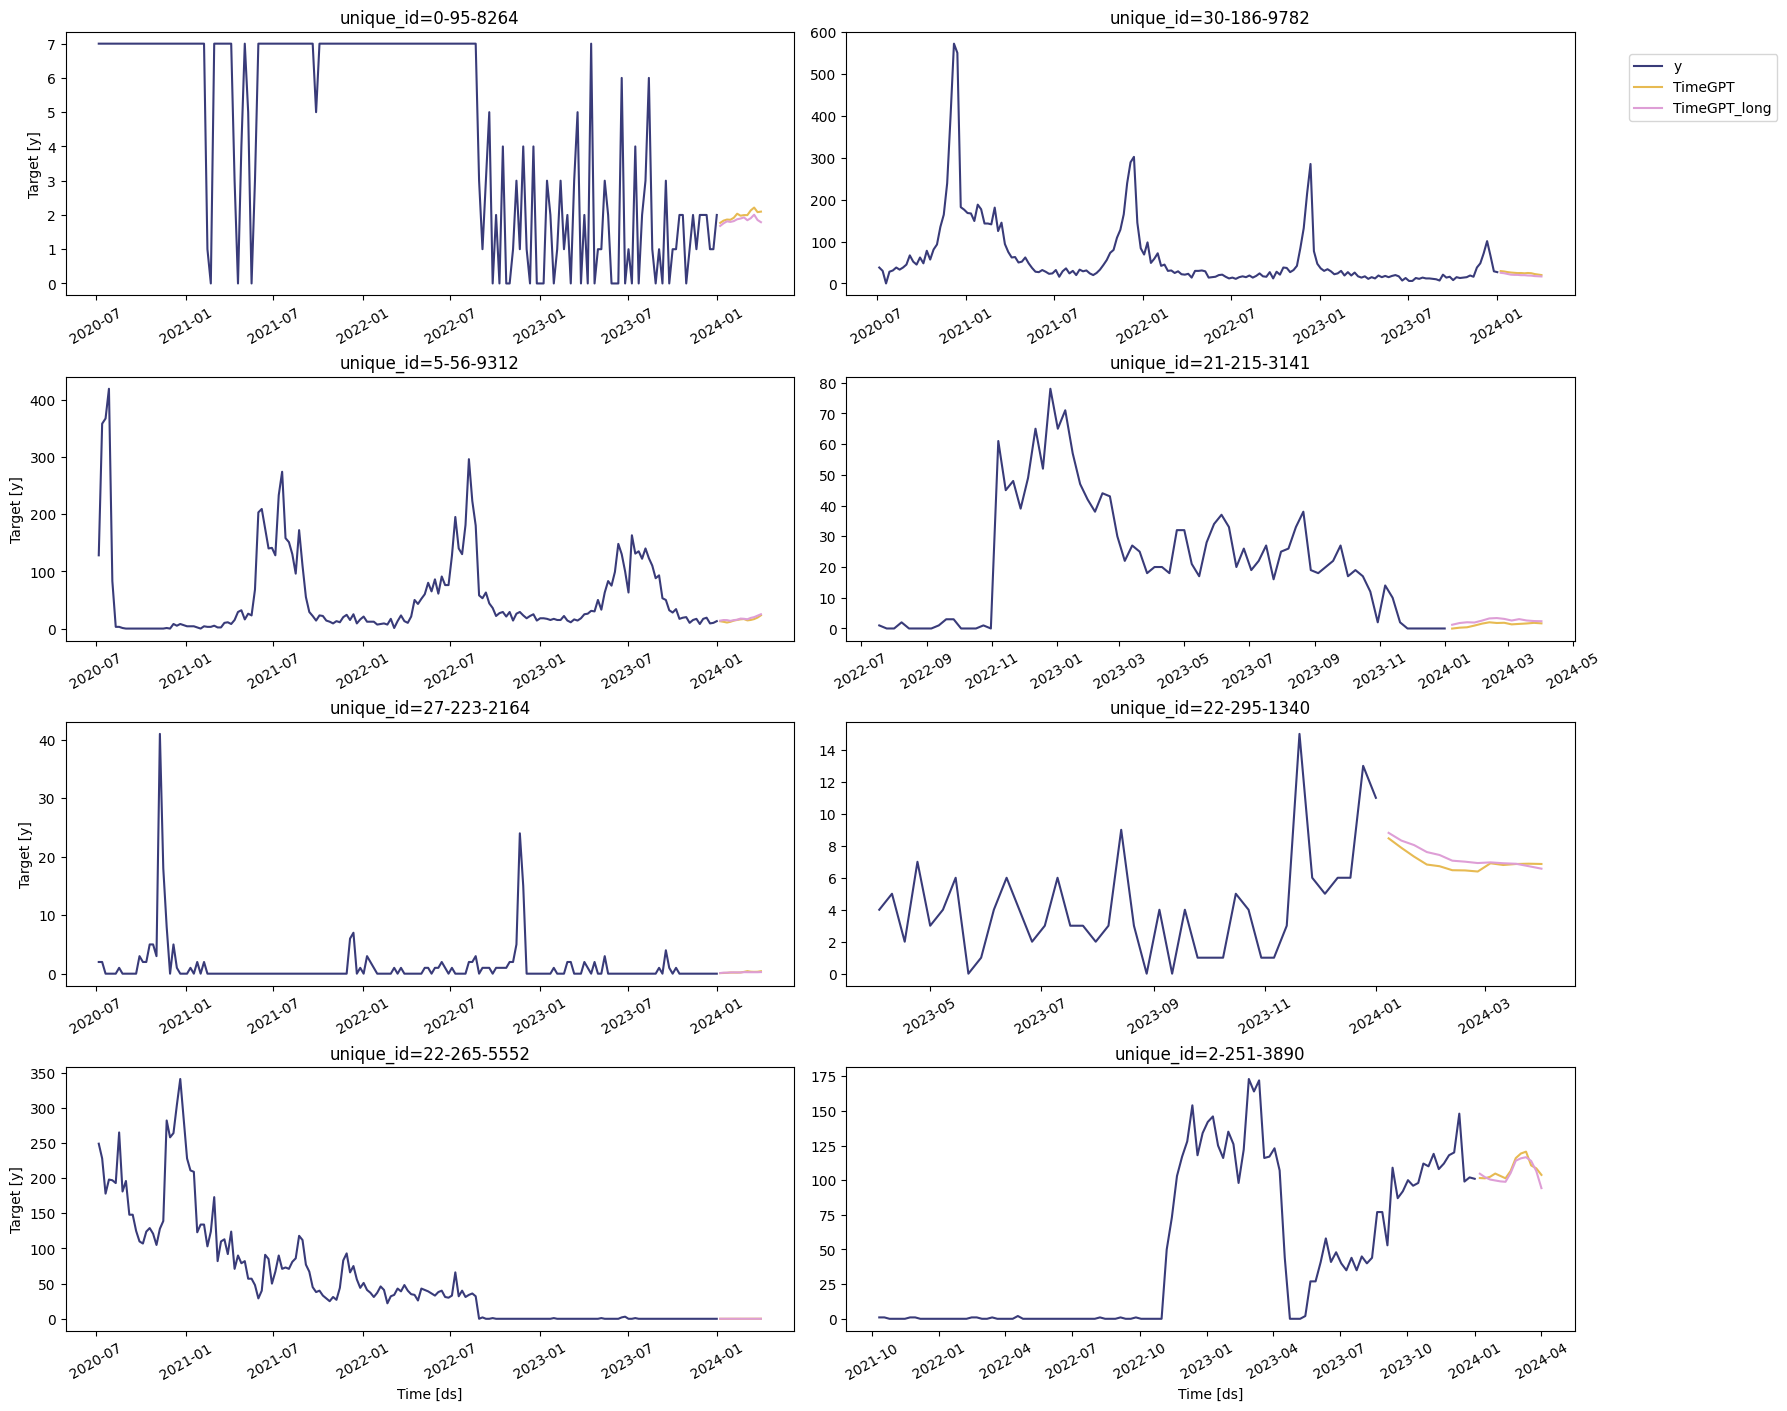

In [5]:
fc_timegpt = fc.merge(fc_long, on=['unique_id', 'ds'], how='inner', suffixes=('', '_long'))

nixtla_client.plot(df, fc_timegpt)

In [6]:
from utils import vn1_competition_evaluation

timegpt_scores = vn1_competition_evaluation(fc_timegpt)

In [7]:
winners_scores = pd.read_parquet('../scores/winners_scores.parquet')

results = pd.concat([winners_scores, timegpt_scores])
results.sort_values(by='score')

,model,score
0,1st place,0.46375
1,TimeGPT_long,0.46507
1,2nd place,0.46568
0,TimeGPT,0.46591
2,3rd place,0.47578
3,4th place,0.47743
4,5th place,0.48081
